# Занятие 5.
__1. Bagging__

__2. Случайный лес__

__3. XGBoost__

Основная часть материалов из этого занятия получены из:
1) [Elements of statistical learning](https://web.stanford.edu/~hastie/Papers/ESLII.pdf)
2) [Открытый курс по машинному обучению Юрия Кашницкого](https://github.com/Yorko/mlcourse.ai)

In [30]:
# Firstly import all required packages
# enable interactive mode of matplotlib
%matplotlib notebook

# import cv2  # python OpenCV
import os  # 
import numpy as np  # lib for arrays
import datetime
import glob
import pandas as pd

import math as mh  # math package

import matplotlib as mpl  
import matplotlib.pyplot as plt  # namespace for plotting
mpl.rcParams['figure.figsize'] = (6,5)  # change default value of plot size

# matplotlib based package for pretty visualization
import seaborn as sns
plt.style.use('seaborn')
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, train_test_split

import time
import pickle  # package for dump & load data
import warnings

# <center> Bagging </center>

Рассмотрим следующий вопрос: можно ли из комбинации слабых моделей создать более сильную модель?

Ответ: да.

В общем случае техника комбинации более слабых моделей в более сильную называется [ансамблями](https://web.engr.oregonstate.edu/~tgd/publications/mcs-ensembles.pdf).

Предпосылкой создания ансамблей служил некоторый накопленный опыт:
* [Мудрость толпы](https://www.ozon.ru/context/detail/id/3352273/) (Wisdom of crowds):
    * В 1906 году британский ученый сэр Фрэнсис Гальтон посещал выставку достижений животноводства, где случайно провел крайне важное наблюдение. На выставке проводился конкурс, в рамках которого всем желающим предлагалось на глаз угадать точный вес забитого быка. Побеждал тот, кто называл самое близкое к истинному значение. Полагая, что справиться с подобной задачей под силу только профессионалу, и чтобы доказать некомпетентность толпы, Гальтон посчитал среднее значение из почти 800 догадок посетителей ярмарки. К удивлению ученого, толпа ошиблась меньше, чем на килограмм: точный вес быка 1198 фунтов, среднее значение толпы 1197 фунтов.
    * Новое и [неслучайное исследование](https://www.nature.com/articles/s41562-017-0247-6) "внутренней" мудрости толпы проводилось нидерландскими и британскими учёными в 2013-2015 г. Исследование проводилось в сети нидерландских казино каждый год в течение последних 7 предновогодних недель. Каждому посетителю было предложено угадать количество мелких предметов в большом бокале. Количество предметов в бокале было от 12 до 23 тысяч штук. По результату было получено 1,2 млн ответов. Данное исследование показало улучшение качества предсказаний с каждой последующей попыткой угадывания, но точность этих предсказаний улучшалась незначительно.   
* **Теорема Кондорсе "О жюри присяжных" (Condorcet Jury Theorem, 1784).** *Если каждый член жюри присяжных имеет независимое мнение, и если вероятность правильного решения члена жюри больше 0,5, то тогда вероятность правильногорешения присяжных в целом возрастает с увеличением количества членов жюри, и стремиться к единице. Еслиже вероятность быть правым у каждого из членов жюри меньше 0.5, то вероятность принятия правильногорешения присяжными в целом монотонно уменьшается и стремится к нулю с увеличением количества присяжных.*

$$\LARGE \mu = \sum_{i=m}^{N}C_N^i p^i (1-p)^{N-i} $$

$ \mu $ - вероятность правильного решения всего жюри;

$ m = floor\left(\dfrac{N}{2} + 1\right) $ - минимальное большинство членов жюри;

$ N $ - число членов жюри;

$ p $ - вероятность правильного решения одного члена жюри;

Если $p>0,5$, то $\mu > p $, если $p<0,5$, то $\mu < p $.

Если $N \rightarrow \infty$ и $p < 0,5$, то $\mu \rightarrow 0$.

Если $N \rightarrow \infty$ и $p>0,5$, то $\mu \rightarrow 1$.

<table>
 <tr>
  <td>
   <img src="images/wisdom.jpg" height="350" width="350">
  </td>
  <td>
   <img src="images/bokal.jpg" height="350" width="350">
  </td>
  <td>
    <img src="images/judge.jpg" height="350" width="350">
  </td>
 </tr>
</table>

## <center> Bagging (Bootstrap aggregation) </center>

Наиболее распространённая техника ансамблирования моделей. *Bagging* был разработан [Лео Брейманом в 1994 году](https://www.stat.berkeley.edu/~breiman/bagging.pdf). Бэггинг основан на статистическом методе [**бутстрэпа (bootstrap)**](http://jeti.uni-freiburg.de/studenten_seminar/stud_sem_SS_09/EfronBootstrap.pdf), который позволяет оценивать многие статистики более сложных распределений.

Опишем технику *bootstrap*. Пусть датасет содержит $ N $ примеров: $\mathbf{X} = \{\mathbf{x_1}, \ldots, \mathbf{x_N}\}$. Создадим новый датасет $ \mathbf{X_B} $ с возвращением. Каждый пример в $ \mathbf{X_B} $ взят случайным образом из $\mathbf{X} $ с равной вероятностью $ \dfrac{1}{N}$. Повторим описанную процедуру $ M $ раз, то есть создадим $ M $ выборок: $ \mathbf{X_B^1}, \ldots, \mathbf{X_B^M} $. 

<img src="images/bootstrap.png"/> 

Применин технику бутстрэпа к обучающей выборке $ \mathbf{X} $ и сгенерируем выборки $ \mathbf{X_B^1}, \ldots, \mathbf{X_B^M} $. На каждой из созданных выборок обучим модель $a_i(x) $. Создадим модель $ a(x) $, которая будет усреднять предсказания каждой из обученной модели: 

$$ \LARGE a(x) = \dfrac{1}{M}\sum_{i=1}^{M} a_i(x) $$.

<img src="images/bagging.jpeg"/> 

Рассмотрим [пример регрессии](https://scikit-learn.org/stable/auto_examples/ensemble/plot_bias_variance.html#sphx-glr-auto-examples-ensemble-plot-bias-variance-py) из документации к Scikit-Learn. Для этого сгенерируем данные в виде функции: 

$$ \Large  f(x) = e^{-x^2} + 1,5 \cdot e^{-(x-2)^2} $$.

In [2]:
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

Установим параметры генерируемых данных:
* `n_repeat` - число итераций для расчета мат. ожиданий
* `n_train` - размер обучающей выборки
* `n_test` - размер тестовой выборки
* `noise` - стандартного отклонение шума
* `random_seed` - состояние генератора случайных чисел

In [3]:
# Settings
n_repeat = 50       # Number of iterations for computing expectations
n_train = 50        # Size of the training set
n_test = 1000       # Size of the test set
noise = 0.1         # Standard deviation of the noise
random_seed = 0

Создадим функцию, которая будет генерировать искомую функцию с заданными параметрами.

In [3]:
def generate(n_samples, noise, n_repeat=1):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X)

    if n_repeat == 1:
        y = f(X) + np.random.normal(0.0, noise, n_samples)
    else:
        y = np.zeros((n_samples, n_repeat))

        for i in range(n_repeat):
            y[:, i] = f(X) + np.random.normal(0.0, noise, n_samples)

    X = X.reshape((n_samples, 1))

    return X, y

Импортируем `DecisionTreeRegressor`, `BaggingRegressor` и `LinearRegression`.

In [18]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

<IPython.core.display.Javascript object>


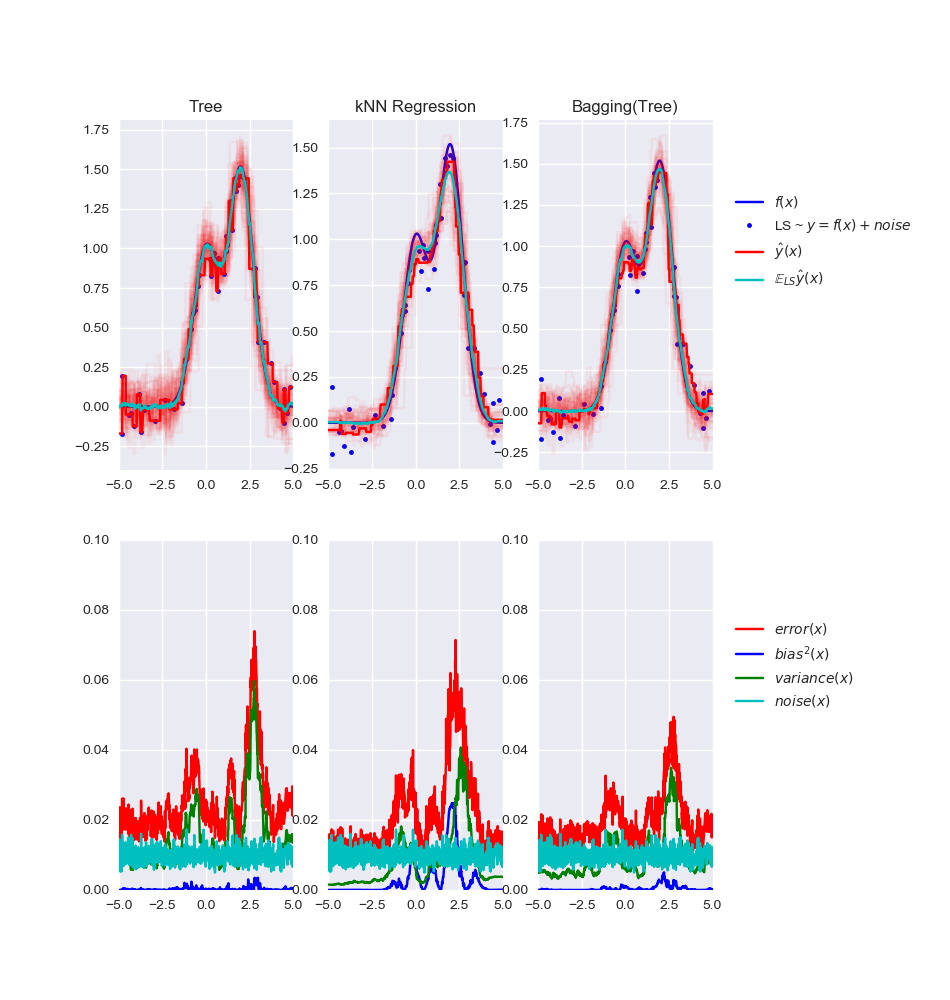

Tree: 0.0255 (error) = 0.0003 (bias^2)  + 0.0152 (var) + 0.0098 (noise)
kNN Regression: 0.0210 (error) = 0.0028 (bias^2)  + 0.0082 (var) + 0.0098 (noise)
Bagging(Tree): 0.0196 (error) = 0.0004 (bias^2)  + 0.0092 (var) + 0.0098 (noise)


In [22]:
# Change this for exploring the bias-variance decomposition of other
# estimators. This should work well for estimators with high variance (e.g.,
# decision trees or KNN), but poorly for estimators with low variance (e.g.,
# linear models).
np.random.seed(random_seed)
estimators = [("Tree", DecisionTreeRegressor()),
              ("kNN Regression", KNeighborsRegressor()),
              ("Bagging(Tree)", BaggingRegressor(DecisionTreeRegressor()))]

n_estimators = len(estimators)

X_train = []
y_train = []

for i in range(n_repeat):
    X, y = generate(n_samples=n_train, noise=noise)
    X_train.append(X)
    y_train.append(y)

X_test, y_test = generate(n_samples=n_test, noise=noise, n_repeat=n_repeat)

plt.figure(figsize=(9.5, 10))

# Loop over estimators to compare
for n, (name, estimator) in enumerate(estimators):
    # Compute predictions
    y_predict = np.zeros((n_test, n_repeat))

    for i in range(n_repeat):
        estimator.fit(X_train[i], y_train[i])
        y_predict[:, i] = estimator.predict(X_test)

    # Bias^2 + Variance + Noise decomposition of the mean squared error
    y_error = np.zeros(n_test)

    for i in range(n_repeat):
        for j in range(n_repeat):
            y_error += (y_test[:, j] - y_predict[:, i]) ** 2

    y_error /= (n_repeat * n_repeat)

    y_noise = np.var(y_test, axis=1)
    y_bias = (f(X_test) - np.mean(y_predict, axis=1)) ** 2
    y_var = np.var(y_predict, axis=1)

    print("{0}: {1:.4f} (error) = {2:.4f} (bias^2) "
          " + {3:.4f} (var) + {4:.4f} (noise)".format(name,
                                                      np.mean(y_error),
                                                      np.mean(y_bias),
                                                      np.mean(y_var),
                                                      np.mean(y_noise)))

    # Plot figures
    plt.subplot(2, n_estimators, n + 1)
    plt.plot(X_test, f(X_test), "b", label="$f(x)$")
    plt.plot(X_train[0], y_train[0], ".b", label="LS ~ $y = f(x)+noise$")

    for i in range(n_repeat):
        if i == 0:
            plt.plot(X_test, y_predict[:, i], "r", label=r"$\^y(x)$")
        else:
            plt.plot(X_test, y_predict[:, i], "r", alpha=0.05)

    plt.plot(X_test, np.mean(y_predict, axis=1), "c",
             label=r"$\mathbb{E}_{LS} \^y(x)$")

    plt.xlim([-5, 5])
    plt.title(name)

    if n == n_estimators - 1:
        plt.legend(loc=(1.1, .5))

    plt.subplot(2, n_estimators, n_estimators + n + 1)
    plt.plot(X_test, y_error, "r", label="$error(x)$")
    plt.plot(X_test, y_bias, "b", label="$bias^2(x)$"),
    plt.plot(X_test, y_var, "g", label="$variance(x)$"),
    plt.plot(X_test, y_noise, "c", label="$noise(x)$")

    plt.xlim([-5, 5])
    plt.ylim([0, 0.1])

    if n == n_estimators - 1:

        plt.legend(loc=(1.1, .5))

plt.subplots_adjust(right=.75)

Итоговое выражение показывает плюсы использования бэггинга. 

Давайте рассмотрим более подробно выражение для регрессии. Запишем ошибку каждой из модели $ b_i(x) $:

$$ \LARGE \varepsilon_i = b_i(x) - y(x), \, i=1\ldots n $$.

Найдем мат. ожидание MSE:

$$ \LARGE \mathbb{E_x}(b_i(x) - y_i)^2 = \mathbb{E_x} \varepsilon_i(x)^2 $$.

Тогда средняя ошибка моделей $ b_i(x) $ имеет вид:

$$\LARGE E_{model} = \dfrac{1}{n} \mathbb{E_x}\sum_{i=1}^{n} \varepsilon^2_i(x) $$.

Ошибки являются несмещёнными и нескореллированными:

$$ \large \mathbb{E}_x\varepsilon_i(x) = 0 $$

$$ \large \mathbb{E_x}\varepsilon_i(x)\varepsilon_j(x) = 0, i \neq j $$

Построим модель регрессора, которая усредняет предсказания каждой из отдельных моделей:

$$ \large a(x) = \dfrac{1}{n} \sum_{i=1}^{n} b_i(x) $$

и найдем её MSE:

$$ \large E_n = \left(\dfrac{1}{n} \sum_{i=1}^{n} b_i(x) - y(x)\right)^2 = \mathbb{E}_x\left( \dfrac{1}{n} \sum_{i=1}^{n} \varepsilon_i \right)^2 = \dfrac{1}{n^2} \mathbb{E}_x \left( \sum_{i=1}^{n} \varepsilon^2_i(x) + \sum_{i \neq j} \varepsilon_i(x)\varepsilon_j(x) \right) =  \dfrac{1}{n} E_{model} $$.

Таким образом, использование бэггинга позволило уменьшить MSE в $n$ раз. Ошибка MSE соответствует компоненте разброса $ Var $  в разложении ошибки:

$$\Huge Err(\overrightarrow{x}) = Bias\left(\hat{f}\right)^2 + Var\left(\hat{f}\right) + \sigma^2$$



# <center> Случайный лес </center>

<img src="images/forest.jpg">


<hr style="height:3px"> 
Алгоритм построения случайного леса для регрессии или классификации
<hr style="height:3px"> 
1. Для $b=1\ldots B $:

    1. Сгенерировать бутстрэп выборку $Z^*$ размера $ N $ от обучающей выборки.
    
    2. Построить решающее дерево $ T_b $ по бутстрэп выборке $Z^*$ рекурсивным перебором следующих шагов для каждого разбиения, пока в каждом листе не будет достигнуто $ n_min $ объектов или пока не достигнем определённой глубины дерева.
    
        1) Выбрать $ m \leq p $ переменных случайным образом из $ p $ переменных.
        
        2) Найти оптимальное разделение по $ m $ переменным.
        
        3) Добавить разделение для найденного оптимального решения.
2. Итог - ансамбль деревьев $ \{ T_b \}^1_B $.

<hr style="height:3px"> 

Для предсказания модели на новых данных $x$:
* Регрессия: $\large \hat{f}_{rf}^B(x) = \dfrac{1}{B} \sum_{b=1}^{B}T_b(x)$.
* Классификация: пусть $\hat{C}_b(x)$ предсказания класса на $ b $-ом дереве случайного леса, тогда $ \large \hat{C}_{rf}^{B}(x) = majority\;vote \{ \hat{C}(x) \}_1^{B} $.

При использовании бэггинга в случае, если переменная распределена i.i.d. (independently and identically distributed) разброс $Var$ уменьшается в $\dfrac{1}{B}$, где $B$ — количество деревьев. В случае наличия попарной корреляции между признаками $\rho$, среднее значение разброса принимает значение:

$$ \large Var_\rho = \rho\sigma^2 + \dfrac{1-\rho}{B}\sigma^2 $$.

По мере увеличения $B$ вторая компонента уменьшается, но первая компонента остается и зависит от коэффициента корреляции $\rho$. В предельном случае значение $\rho$ и будет определять допустимое значение разброса $Var$.

При построении каждого дерева из случайного леса  какое случайное значение признаков $m$ стоит выбрать? 
Практика показала, что оптимальными значениями являются $m = \sqrt{p}$ для классификации и $ m=\dfrac{p}{3}$.

В случае регрессии случайный лес $ \left\{ T(x; \Theta_b) \right\}^B_1$ ($\Theta_b $ - параметры $b$-го дерева) предсказание случайного леса определяется следующим выражением:

$$ \hat{f}_{rf}^B(x) = \dfrac{1}{B} \sum_{b=1}^{B} T(x;\Theta_b) $$.

Логично ожидать, что при уменьшении $ m $ в случае наличии корреляции в данных корреляция между деревьями будет уменьшаться и, тем самым, снижаться средний разброс. Среди дерьевев решений коэффициент корреляции обычно принимается равным $\rho(x) = 0.05 $.

Такое рассуждение работает не для всех моделей при построении бэггиннга. Лучше всего это работает на сложных моделях, т.е. моделях с низким смещением $Bias$ и высоким $Variance$. В случае линейных моделей попарный коэффициент корреляции достигает значений $50\%$.

Давайте посмотрим на процесс обучения с точки зрения валидации и тестирования данных.
Одной из характеристик случайного леса во время обучения является наличие Out-Of-Bag (OOB) ошибки: *для каждого примера $z_i = (x_i, y_i) $ построенная модель случайного леса будет предсказывать усредненем только те данные, которые не содержаться в бутстрэп выборке $z_i$.* OOB ошибка по смыслу близка к $N-fold$ кросс-валидации. В отличие от традиционных подходов, случайный лес при построении обучается с использованием кросс-валидации. Во время обучения стабилизации OOB ошибки позволяет оценить качество во время обучения и момент остановки процесса обучения.

Рассмотрим реализацию `RandomForestRegressor` в библиотеке [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) на примере предсказания стоимости недвиджимости в датасете [House Sales](https://www.kaggle.com/harlfoxem/housesalesprediction).

In [16]:
# import model class
from sklearn.ensemble import RandomForestRegressor

In [17]:
# import dataset
df = pd.read_csv('./dataset/kc_house_data.csv', index_col='id')

In [18]:
# see the dataset 
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,,,,,,,,,,,,,,,,,,,,
7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [19]:
# create targets - price and remove data for simplifying and price from dataset
y = df['price']
df = df.drop(['price', 'date'], axis=1)

In [20]:
# see corrected dataset
df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,,,,,,,,,,,,,,,,,,
7129300520,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
6414100192,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
5631500400,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2487200875,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
1954400510,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Инициализируем модель:

In [21]:
rf = RandomForestRegressor(oob_score=True)

И обучим её на данных, присваивая разное количество деревьев:

In [22]:
min_estimators = 2
max_estimators = 30
oob_errors = []
for i in range(min_estimators, max_estimators + 1):
    print('Fit with {} estimators..'.format(i))
    rf.set_params(n_estimators=i)
    rf.fit(df, y)
    
    # Record the OOB error for each `n_estimators=i` setting.
    oob_error = 1 - rf.oob_score_
    oob_errors.append((i, oob_error))
oob_errors = np.array(oob_errors)

Fit with 2 estimators..


f:\venvs\fil\lib\site-packages\sklearn\ensemble\forest.py:732: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable oob estimates.
  warn("Some inputs do not have OOB scores. "


Fit with 3 estimators..


f:\venvs\fil\lib\site-packages\sklearn\ensemble\forest.py:732: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable oob estimates.
  warn("Some inputs do not have OOB scores. "


Fit with 4 estimators..


...

f:\venvs\fil\lib\site-packages\sklearn\ensemble\forest.py:732: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable oob estimates.
  warn("Some inputs do not have OOB scores. "


Fit with 6 estimators..


f:\venvs\fil\lib\site-packages\sklearn\ensemble\forest.py:732: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable oob estimates.
  warn("Some inputs do not have OOB scores. "


Fit with 7 estimators..


KeyboardInterrupt: 

Визуализируем OOB ошибку от количества деревьев:

<IPython.core.display.Javascript object>


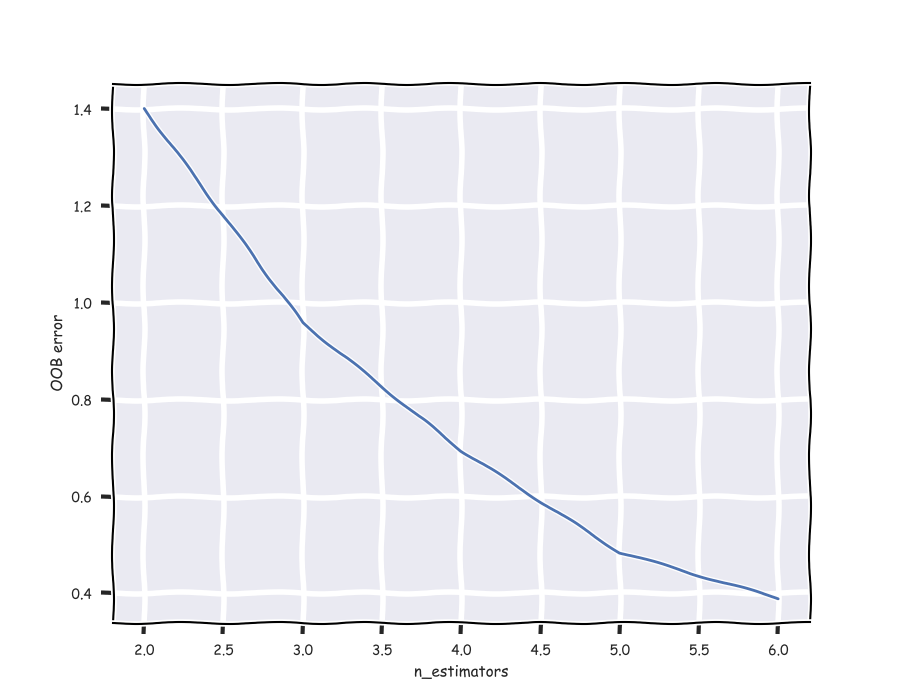

In [23]:
plt.xkcd()
plt.figure(figsize=(9,7))
oob_errors = np.array(oob_errors)
plt.plot(oob_errors[:, 0], oob_errors[:, 1])
plt.grid()
_ = plt.xlabel('n_estimators')
_ = plt.ylabel('OOB error')

На практике OOB ошибка всегда будет иметь более оптимистичное значение. 

Признаки, позволяющие более качественно проводить разбиения в каждом дереве, могут быть оценены для последующего анализа модели. Для этого учитывается каждое из разбиений и по какому признаку оно выполняется.

In [24]:
features = df.columns
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(9, 7))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='g', align='center')
_ = plt.yticks(range(len(indices)), [features[i] for i in indices])
_ = plt.xlabel('Relative Importance')
_ = plt.grid()

ZeroDivisionError: division by zero



Плюсы:
* обладает хорошим качеством: на большинстве задач лучше линейных моделей, а точность сравнима с точностью бустинга
* не чувствителен к выбросам из-за случайного сэмплирования данных
* отсутствие требований к предобработке данных
* Out-of-bag ошибка
* небольшая чувствительность к гиперпараметрам, то есть даёт качественный результат прямо из коробки
* способен эффективно обрабатывать данные с большим числом признаков и классов
* одинаково хорошо обрабатывет как непрерывные, так и дискретные признаки
* редко переобучается, на практике добавление деревьев почти всегда только улучшает композицию, но на валидации, после достижения определенного количества деревьев, кривая обучения выходит на асимптоту
* для случайного леса существуют методы оценивания значимости отдельных признаков в модели
* хорошо работает с пропущенными данными; сохраняет хорошую точность, если большая часть данных пропущенна
* предполагает возможность сбалансировать вес каждого класса на всей выборке, либо на подвыборке каждого дерева
* вычисляет близость между парами объектов (proximity plot), которые могут использоваться при кластеризации, обнаружении выбросов или (путем масштабирования) дают интересные представления данных
* возможности, описанные выше, могут быть расширены до немаркированных данных, что приводит к возможноти делать кластеризацию и визуализацию данных, обнаруживать выбросы
* высокая параллелизуемость и масштабируемость

Минусы:
* не позволяет качественно интерпретировать зависимости
* нет формальных выводов (p-values), доступных для оценки важности переменных
* алгоритм работает хуже многих линейных методов, когда в выборке очень много разреженных признаков (тексты, Bag of words)
* случайный лес не умеет экстраполировать, в отличие от той же линейной регрессии (но это можно считать и плюсом, так как не будет экстремальных значений в случае попадания выброса)
* алгоритм склонен к переобучению на некоторых задачах, особенно на зашумленных данных
* для данных, включающих категориальные переменные с различным количеством уровней, случайные леса предвзяты в пользу признаков с большим количеством уровней: когда у признака много уровней, дерево будет сильнее подстраиваться именно под эти признаки, так как на них можно получить более высокую точность
* если данные содержат группы коррелированных признаков, имеющих схожую значимость для меток, то предпочтение отдается небольшим группам перед большими
* больший размер получающихся моделей: требуется $\large O(NK)$ памяти для хранения модели, где $\large K $ — число деревьев


# <center> Бустинг </center>

*«When in doubt – use xgboost»   
Owen Zhang, top-2 on Kaggle.*

Бустинг - одна из самых сильных идей в машинном обучении за последние 30 лет. 

Идея простая: используя модели, точность которых немногим выше случайного угадывания, построить сильную модель. Тогда можно записать результат работы такого представления:

$$\large f(x) = \sum_{m=1}^{M}\beta_m\,b(x;\gamma_m), $$

$ \beta_m, m=1, \ldots, M $ - коэффициенты для каждой из модели,

$ b(x;\gamma) \in \mathbb{R} $ - функция, характеризуемая параметрами $\gamma$.



Одной из первых реализованных моделей бустинга была модель [AdaBoost.M1](https://web.eecs.utk.edu/~leparker/Courses/CS425-528-fall10/Handouts/AdaBoost.M1.pdf).

<hr style="height:3px"> 

**Алгоритм AdaBoost.M1**

<hr style="height:3px"> 

Опишем её более формально:
1. Инициализируем веса для каждого из примера в выборке $w_i = \dfrac{1}{N}, i = 1,\,2,\ldots, N$.
2. Для m=1 до M:
    a. Обучить классификатор $G_m(x)$ на обучающей выборке используя веса $w_i$.
    b. Вычислить ошибку
    
    $$ \large err_m = \dfrac{\sum_{i=1}^{N} w_i I(y_i \neq G_m(x_i))}{\sum_{i=1}^{N} w_i} $$
    
    c. Вычислить $\large \alpha_m = \log \left( \dfrac{1-err_m}{err_m} \right) $
    
    d. $ \large w_i \leftarrow w_i * exp[\alpha_m * I(y_i \neq G_m(x_i)], i = 1, 2, \ldots, N  $
    
3. Выход:
$$ \large G(x) = sign\left[ \sum_{m=1}^{M} \alpha_m G_m(x) \right] $$

<hr style="height:3px"> 


Рассмотрим функцию ошибки, которую пытается минимизировать классификатор:

$$\large \overline{err} = \dfrac{1}{N} \sum_{i=1}^{N} I (y_i \neq G(x_i)) $$

Цель бустинга оптимизировать эту ошибку, последовательно обучая модель на перевзвешенных данных и добавляя модель к исходному ансамблю. Функция ошибки напрямую не является дифференцируемой. Вместо этого используют некоторую верхнюю оценку, т.е. аппроксимацию этой функции.

Для различных аппроксимаций пороговой функции потерь $[z < 0]$ получаются различные виды бустинга:
- $e^{-z}$ - AdaBoost
- $\log_2(1 + e^{-z})$ - LogitBoost
- $(1 - z)^2$ - GentleBoost
- $e^{-cz(z+a)}$ - BrownBoost
- другие

<IPython.core.display.Javascript object>


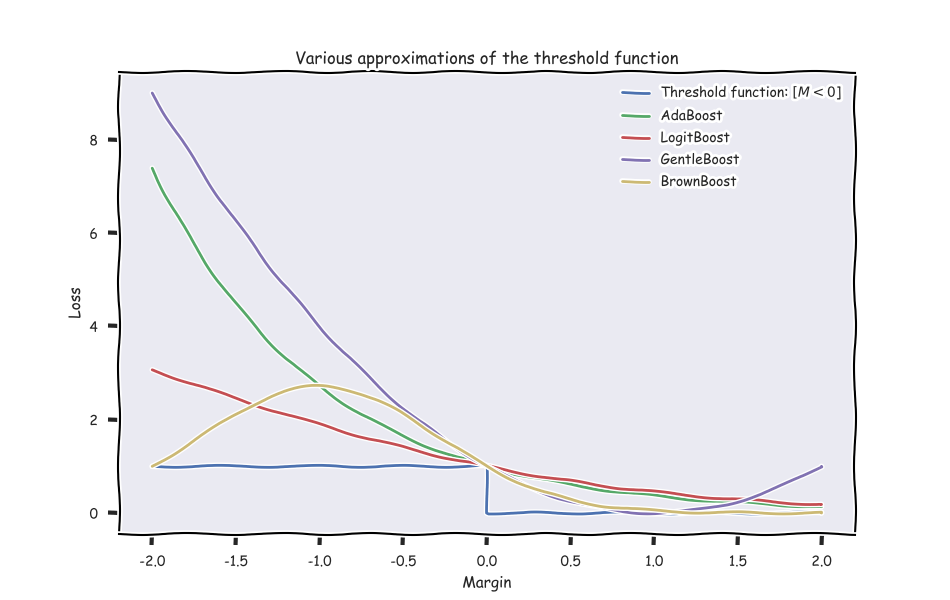

In [25]:
x = np.linspace(-2, 2, 500)

plt.figure(figsize=(9.5,6))
plt.plot(x, x < 0, lw=2, label='Threshold function: $[M < 0$]')
plt.plot(x, np.exp(-x), lw=2, label='AdaBoost')
plt.plot(x, np.log2(1 + np.exp(-x)), lw=2, label='LogitBoost')
plt.plot(x, (1 - x) ** 2, lw=2, label='GentleBoost')
plt.plot(x, np.exp(-x * (x + 2)), lw=2, label='BrownBoost')
plt.title('Various approximations of the threshold function')
plt.legend(loc='best')
plt.xlabel('Margin')
plt.ylabel('Loss');

Проиллюстрируем пример работы AdaBoost на игрушечном примере с использованием деревьев решений:

<img src="images/adaboost.png">

Алгоритм бустинга в общем смысле пытается минимизировать некоторую функцию потерь, определяемую в общем случае выражением:

$$ \Large \min_{\{\beta_m, \gamma_m\}_1^M} \sum_{i=1}^{N} L \left( y_i, \sum_{m=1}^{M} \beta_m b(x_i;\gamma_m) \right) $$.

Но для многих функций потерь оптимизация по параметрам модели для всех моделей композиции является вычислительно затратной, поэтому вместо общей функции потерь используют оптимизацию функции с моделью при её добавлении:

$$ \Large \min_{\beta, \gamma} \sum_{i=1}^{N} L \left( y_i, \beta b(x_i; \, \gamma) \right) $$.

В таком случае алгоритм бустинга описывает последовательно добавление функций с оптимизируемыми параметрами к ансамблю моделей с фиксированными параметрами:

<hr style="height:3px"> 

**Алгоритм Forward Stagewise Additive Modeling**

<hr style="height:3px"> 

1. Инициализиурем функцию $f_0(x) = 0$
2. Для $m = 1, ..., \ldots M$:

    a. Вычислить:
    
    $$\Large (\beta_m, \gamma_m) = \arg \, \min_{\beta, \gamma} \sum_{i=1}^{N} L(y_i, f_{m-1} (x_i) + \beta\,b(x_i, \gamma)) $$.
    
    b. Присвоить:
    $$ \Large f_m(x) = f_{m-1}(x) + \beta_m b(x; \gamma_m) $$

<hr style="height:3px"> 

Для квадратичной функции потерь $ L(y, f(x)) = (y-f(x))^2 $:

$$\Large L(y_i, f_{m-1}(x_i) + \beta\,b(x_i, \gamma)) = (y_i - f_{m-1}(x_i) - \beta\, b(x_i; \gamma))^2 = (r_{im} - \beta\,b(x_i;\gamma))^2 $$,

$ r_{im} = y_i - f_{m-1}(x_i) $ - остатки, то есть разница между текущим ансамблем и $i$-м наблюдением

<img src="images/adaboost.gif">


**Обучим модель XGBoost Regressor на данных по предсказанию цены**

Посмотрим на данные еще раз, чтобы убедиться в их правильности:

In [28]:
df.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,,,,,,,,,,,,,,,,,,
7129300520,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
6414100192,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
5631500400,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2487200875,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
1954400510,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [29]:
y[:5]

id
7129300520    221900.0
6414100192    538000.0
5631500400    180000.0
2487200875    604000.0
1954400510    510000.0
Name: price, dtype: float64

[Поделим](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) выборку на обучающую и тестовую в соотношении 70/30:

In [31]:
X_train, X_test, y_train, y_test = train_test_split(df, y, random_state=17)

In [ ]:
X_train

Импортируем xgboost

Импортируем XGBoost модель из библиотеки. Существует несколько вариантов использования XGBoost: на Python распространены [обёртка](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) под библиотеку Scikit-Learn и исходный интерфейс к XGBoost.

In [32]:
import xgboost as xgb

In [106]:
params = {
    'objective': 'reg:linear',
    'max_depth': 15,
    'learning_rate': 0.1,
#     'silent': 0.0,
    'n_estimators': 500,
}
num_rounds = 1000

In [107]:
xgb_model = xgb.XGBRegressor(**params)

In [108]:
# use native interface
dtrain = xgb.DMatrix(X_train, y_train)
dtest = xgb.DMatrix(X_test, y_test)

In [109]:
# see error for train and test examples due training
watchlist  = [(dtest,'test'), (dtrain,'train')]

In [110]:
xgb_model = xgb.train(params, dtrain, num_rounds, watchlist)

[09:26:08] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 474 extra nodes, 0 pruned nodes, max_depth=14
[0]	test-rmse:605400	train-rmse:588107
[09:26:08] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 558 extra nodes, 0 pruned nodes, max_depth=15
[1]	test-rmse:551298	train-rmse:533644
[09:26:08] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 604 extra nodes, 0 pruned nodes, max_depth=15
[2]	test-rmse:502899	train-rmse:484570
[09:26:08] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 702 extra nodes, 0 pruned nodes, max_depth=15
[3]	test-rmse:458917	train-rmse:440394
[09:26:08] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 794 extra nodes, 0 pruned nodes, max_depth=15
[4]	test-rmse:419616	train-rmse:400463
[09:26:08] C:\Users\Administrator\Deskto

[09:26:12] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 3782 extra nodes, 0 pruned nodes, max_depth=15
[43]	test-rmse:131939	train-rmse:26697.7
[09:26:12] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 3542 extra nodes, 0 pruned nodes, max_depth=15
[44]	test-rmse:131750	train-rmse:25855.5
[09:26:12] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 3728 extra nodes, 0 pruned nodes, max_depth=15
[45]	test-rmse:131599	train-rmse:25063.1
[09:26:12] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 3728 extra nodes, 0 pruned nodes, max_depth=15
[46]	test-rmse:131415	train-rmse:24345.9
[09:26:12] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 3410 extra nodes, 0 pruned nodes, max_depth=15
[47]	test-rmse:131273	train-rmse:23719.1
[09:26:12] C:\Users\Admin

[09:26:15] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1518 extra nodes, 0 pruned nodes, max_depth=15
[86]	test-rmse:129827	train-rmse:15557.2
[09:26:15] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1592 extra nodes, 0 pruned nodes, max_depth=15
[87]	test-rmse:129833	train-rmse:15434.8
[09:26:15] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 982 extra nodes, 0 pruned nodes, max_depth=15
[88]	test-rmse:129832	train-rmse:15393.2
[09:26:15] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 2450 extra nodes, 0 pruned nodes, max_depth=15
[89]	test-rmse:129834	train-rmse:15240.9
[09:26:15] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1278 extra nodes, 0 pruned nodes, max_depth=15
[90]	test-rmse:129837	train-rmse:15124.3
[09:26:15] C:\Users\Admini

[09:26:18] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1042 extra nodes, 0 pruned nodes, max_depth=15
[128]	test-rmse:129871	train-rmse:11823.6
[09:26:18] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 2886 extra nodes, 0 pruned nodes, max_depth=15
[129]	test-rmse:129867	train-rmse:11766.6
[09:26:18] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 2600 extra nodes, 0 pruned nodes, max_depth=15
[130]	test-rmse:129874	train-rmse:11702.3
[09:26:18] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1656 extra nodes, 0 pruned nodes, max_depth=15
[131]	test-rmse:129875	train-rmse:11673.9
[09:26:18] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 3266 extra nodes, 0 pruned nodes, max_depth=15
[132]	test-rmse:129880	train-rmse:11582.9
[09:26:18] C:\Users\

[09:26:21] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 3468 extra nodes, 0 pruned nodes, max_depth=15
[170]	test-rmse:129950	train-rmse:10241
[09:26:21] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1208 extra nodes, 0 pruned nodes, max_depth=15
[171]	test-rmse:129952	train-rmse:10225.7
[09:26:21] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 2080 extra nodes, 0 pruned nodes, max_depth=15
[172]	test-rmse:129951	train-rmse:10199.1
[09:26:21] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1554 extra nodes, 0 pruned nodes, max_depth=15
[173]	test-rmse:129953	train-rmse:10175.9
[09:26:21] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 3366 extra nodes, 0 pruned nodes, max_depth=15
[174]	test-rmse:129953	train-rmse:10138.6
[09:26:21] C:\Users\Ad

...

[09:27:06] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 2360 extra nodes, 0 pruned nodes, max_depth=15
[800]	test-rmse:130057	train-rmse:8985.59
[09:27:06] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1188 extra nodes, 0 pruned nodes, max_depth=15
[801]	test-rmse:130057	train-rmse:8985.59
[09:27:06] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1024 extra nodes, 0 pruned nodes, max_depth=15
[802]	test-rmse:130057	train-rmse:8985.59
[09:27:06] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 826 extra nodes, 0 pruned nodes, max_depth=15
[803]	test-rmse:130057	train-rmse:8985.59
[09:27:06] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1876 extra nodes, 0 pruned nodes, max_depth=15
[804]	test-rmse:130057	train-rmse:8985.59
[09:27:06] C:\Users\A

[09:27:09] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1254 extra nodes, 0 pruned nodes, max_depth=15
[842]	test-rmse:130057	train-rmse:8985.58
[09:27:09] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 658 extra nodes, 0 pruned nodes, max_depth=15
[843]	test-rmse:130057	train-rmse:8985.58
[09:27:09] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 3710 extra nodes, 0 pruned nodes, max_depth=15
[844]	test-rmse:130057	train-rmse:8985.58
[09:27:09] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 4712 extra nodes, 0 pruned nodes, max_depth=15
[845]	test-rmse:130057	train-rmse:8985.58
[09:27:09] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 3178 extra nodes, 0 pruned nodes, max_depth=15
[846]	test-rmse:130057	train-rmse:8985.58
[09:27:09] C:\Users\A

[09:27:12] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1340 extra nodes, 0 pruned nodes, max_depth=15
[884]	test-rmse:130057	train-rmse:8985.58
[09:27:12] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1920 extra nodes, 0 pruned nodes, max_depth=15
[885]	test-rmse:130057	train-rmse:8985.58
[09:27:12] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 476 extra nodes, 0 pruned nodes, max_depth=15
[886]	test-rmse:130057	train-rmse:8985.58
[09:27:12] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 2486 extra nodes, 0 pruned nodes, max_depth=15
[887]	test-rmse:130057	train-rmse:8985.58
[09:27:12] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1888 extra nodes, 0 pruned nodes, max_depth=15
[888]	test-rmse:130057	train-rmse:8985.58
[09:27:12] C:\Users\A

[09:27:14] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 404 extra nodes, 0 pruned nodes, max_depth=15
[926]	test-rmse:130057	train-rmse:8985.57
[09:27:14] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1380 extra nodes, 0 pruned nodes, max_depth=15
[927]	test-rmse:130057	train-rmse:8985.57
[09:27:15] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 2610 extra nodes, 0 pruned nodes, max_depth=15
[928]	test-rmse:130057	train-rmse:8985.57
[09:27:15] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 2364 extra nodes, 0 pruned nodes, max_depth=15
[929]	test-rmse:130057	train-rmse:8985.57
[09:27:15] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 2908 extra nodes, 0 pruned nodes, max_depth=15
[930]	test-rmse:130057	train-rmse:8985.57
[09:27:15] C:\Users\A

[09:27:17] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 976 extra nodes, 0 pruned nodes, max_depth=15
[968]	test-rmse:130057	train-rmse:8985.57
[09:27:18] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 1016 extra nodes, 0 pruned nodes, max_depth=15
[969]	test-rmse:130057	train-rmse:8985.57
[09:27:18] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 2486 extra nodes, 0 pruned nodes, max_depth=15
[970]	test-rmse:130057	train-rmse:8985.57
[09:27:18] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 646 extra nodes, 0 pruned nodes, max_depth=15
[971]	test-rmse:130057	train-rmse:8985.57
[09:27:18] C:\Users\Administrator\Desktop\xgboost\src\tree\updater_prune.cc:74: tree pruning end, 1 roots, 628 extra nodes, 0 pruned nodes, max_depth=15
[972]	test-rmse:130057	train-rmse:8985.57
[09:27:18] C:\Users\Adm

In [112]:
predict_vals = xgb_model.predict(dtest)

In [113]:
predict_vals

array([568521.25, 473422.1 , 366565.47, ..., 530962.25, 632490.4 ,
       542576.06], dtype=float32)

In [114]:
from sklearn.metrics import mean_squared_error

In [115]:
mean_squared_error(predict_vals, y_test)

16914813193.85936

<IPython.core.display.Javascript object>


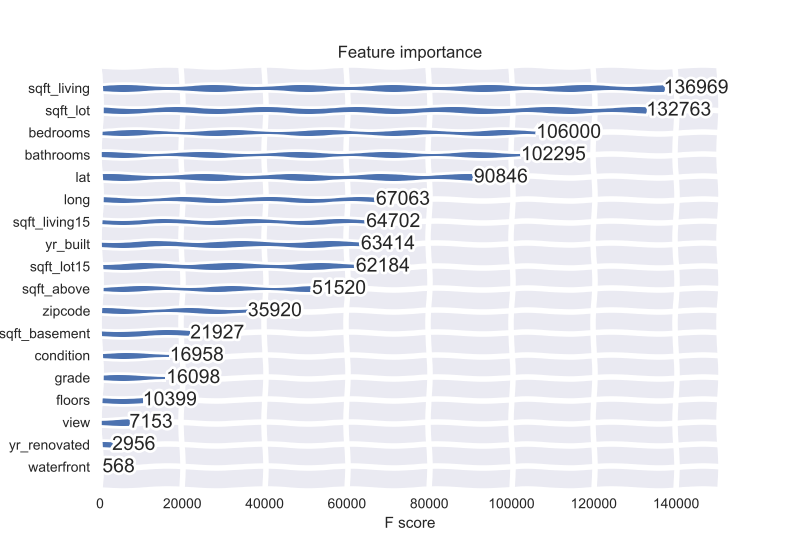

In [116]:
xgb.plot_importance(xgb_model);

[XGBoost параметры](https://xgboost.readthedocs.io/en/latest/):

Выделяют три группы параметров:
- Общие параметры, отвечающие за базовый алгоритм для бустинга и распараллеливание.
- Параметры выбранного базового алгоритма.
- Параметры обучения, отвечающие за функцию потерь и метрику качества на валидации.

**1. Общие параметры:**
- booster [default=gbtree] - тип базового алгоритма для бустинга: дерево решений gbtree или линейная модель gblinear. 
- silent [default=0] - выдавать (silent=0) или нет (silent=1) сообщения по ходу работы алгоритма.
- nthread [default to maximum number of threads available if not set] - число нитей доступных для параллельной работы xgboost.

**2. Параметры базового алгоритма:**

**2.1. Дерево решений:**
- eta [default=0.3] - темп обучения, перед добавлением дерева в композицию оно умножается на eta. Используется для предотвращения переобучения за счёт "сокращения" весов базовых алгоритмов, делая модель более консервативной. Чем меньше eta, тем больше нужно итераций num_boost_round для обучения модели с хорошим качеством. Диапазон: [0, 1]
- gamma [default=0] - минимальное снижение значения функции потерь, необходимое для дальнейшего разбиения вершины дерева. Большие значения gamma > 0 приводят к более консервативным моделям. Диапазон: [0, $\infty$).
- max_depth [default=6] - максимальная глубина дерева. Диапазон: [1, $\infty$). 
- min_child_weight [default=1] - минимальное необходимое (взвешенное) число примеров в каждой вершине. Чем больше, тем более консервативна итоговая модель. Диапазон: [0, $\infty$).
- max_delta_step [default=0] - обычно равен нулю. Положительные значения используются при несбалансированных классах для ускорения сходимости. Диапазон [0, $\infty$).
- subsample [default=1] - доля выборки, используемая для обучения каждого дерева. Если subsample < 1, то выбирается случайная подвыборка, что помогает в борьбе с переобучением. Диапазон: (0, 1]
- colsample_bytree [default=1] - доля признаков, используемая для обучения каждого дерева. Диапазон: (0, 1]
- lambda [default=1] - коэффициент перед $L_2$-регуляризатором в функции потерь.
- alpha [default=0] - коэффициент перед $L_1$-регуляризатором в функции потерь.

**2.2. Линейная модель:**
- lambda [default=0] - коэффициент перед $L_2$-регуляризатором вектора весов в функции потерь.
- alpha [default=0] - коэффициент перед $L_1$-регуляризатором вектора весов в функции потерь.
- lambda_bias [default=0] - коэффициент перед $L_2$-регуляризатором смещения (свободного члена) в функции потерь.

**3. Параметры задачи обучения:**
- objective [default=reg:linear] - используемая при обучении функция потерь:
    - "reg:linear" – линейная регрессия.
    - "reg:logistic" – логистическая регрессия.
    - "binary:logistic" – логистическая регрессия для бинарной классификации, на выходе - вероятность.
    - "binary:logitraw" – то же самое, но на выходе - значение до его преобразования логистической функцией.
    - "count:poisson" – регрессия Пуассона (используется для оценки числа каких-то событий, счётный признак), на выходе - матожидания распределения Пуассона. В этом случае max_delta_step автоматически устанавливается равным 0.7.
    - "multi:softmax" – обобщение логистической регрессии на многоклассовый случай. При этом нужно задать параметр num_class.
    - "multi:softprob" – то же самое, но на выходе - вектор размера ndata * nclass, который можно преобразовать в матрицу, содержащую вероятности отнесения данного объекта к данному классу.
    - "rank:pairwise" – используется для задач ранжирования.
- base_score [default=0.5] - инициализация значения модели для всех примеров, глобальное смещение.
- eval_metric [default according to objective] - метрика качества на валидационной выборке (по умолчанию соответствует функции потерь: rmse - для регрессии, error - для классификации, mean average precision - для ранжирования). Выбрать можно одну из следующих метрик:
    - "rmse": root mean square error.
    - "logloss": минус логарифм правдоподобия.
    - "error": доля ошибок для бинарной классификации.
    - "merror": то же самое для многоклассовой классификации.
    - "mlogloss": logloss для многоклассовой классификации.
    - "auc": AUC.
    - "ndcg": Normalized Discounted Cumulative Gain.
    - "map": Mean average precision.
    - "ndcg@n",”map@n”: здесь n - целое число, первые n позиций в списке не учитываются.
    - "ndcg-",”map-”,”ndcg@n-”,”map@n-”: списку из всех положительных примеров будет присвоено значение 0 (вместо 1).
- seed [default=0] - для воспроизводимости "случайности".

**Параметры в xgboost.train**:
- params (dict) – параметры, описанные выше.
- dtrain (DMatrix) – обучающая выборка.
- num_boost_round (int) – число итераций бустинга.
- evals (list) – список для оценки качества во время обучения.
- obj (function) – собственная функция потерь.
- feval (function) – собственная функция для оценки качества.
- maximize (bool) – нужно ли максимизировать feval.
- early_stopping_rounds (int) – активирует early stopping. Ошибка на валидации должна уменьшаться каждые early_stopping_rounds итераций для продолжения обучения. Список evals должен быть не пуст. Возвращается модель с последней итерации. Если произошел ранний останов, то модель будет содержать поля: bst.best_score и bst.best_iteration.
- evals_result (dict) – результаты оценки качества.
- verbose_eval (bool) – вывод значения метрики качества на каждой итерации бустинга.
- learning_rates (list or function) – коэффициент скорости обучения для каждой итерации - list l: eta = l[boosting round] - function f: eta = f(boosting round, num_boost_round).
- xgb_model (file name of stored xgb model or ‘Booster’ instance) – возможность продолжить обучения имеющейся модели XGB.